# 🏥 Hastane Randevusu No-Show Tahmini // - In Frames -
## DATA LEAGUE '26 — Kaggle Yarışması Çözüm Notebook'u

---

## 📋 İçindekiler
1. [Problem Tanımı](#1-problem-tanimi)
2. [Veri Seti](#2-veri-seti)
3. [Metodoloji](#3-metodoloji)
4. [Akış Şeması](#4-akis-semasi)
5. [Teknik Yaklaşım](#5-teknik-yaklasim)
6. [Sonuçlar](#6-sonuclar)

---

## 1. Problem Tanimi

Sağlık sistemlerinde **randevuya gelmeme (No-Show)** problemi,
hastaneler için ciddi kaynak israfına yol açmaktadır.
Boşa giden randevular; doktor, personel ve oda zamanını tüketirken
diğer hastaların bekleme sürelerini de uzatmaktadır.

Bu yarışmada görev, **200.000'den fazla randevu kaydı** üzerinde
her randevu için hastanın gelmeme olasılığını `(0-1 arası float)`
tahmin eden en güçlü modeli geliştirmektir.

> **Hedef Değişken:** `label_noshow`
> - `1` → Hasta randevuya gelmedi *(No-Show)*
> - `0` → Hasta randevuya geldi *(Show)*

### Neden Bu Problem Zor?

- Sınıf dengesizliği: Veride **%24 No-Show**, %76 Show
- **Cold-start klinikleri:** Test setinin ~%7'si
  eğitim verisinde hiç görülmemiş yeni kliniklerden oluşuyor
- **Zaman bazlı ayrım:** Train Ocak-Ekim 2025,
  Test Kasım-Aralık 2025 — gelecek tahmini senaryosu
- **Sentetik veri:** İlişkiler mekanik ve az sayıda
  değişkene bağlı — feature engineering sınırlı etki yaratıyor

---

## 2. Veri Seti

Yarışma **4 tablo** içermektedir:

| Dosya | Satır | Açıklama |
|---|---|---|
| `appointments_train.csv` | 200,000 | Eğitim randevuları + hedef değişken |
| `appointments_test.csv` | 80,000 | Test randevuları (tahmin edilecek) |
| `patients.csv` | 30,000 | Hasta demografisi *(lookup tablosu)* |
| `clinics.csv` | 36 | Klinik özellikleri *(lookup tablosu)* |

### Tablo İlişkileri
```
appointments_*  ──(patient_id)──▶  patients.csv
appointments_*  ──(clinic_id) ──▶  clinics.csv
```

### Önemli Veri Özellikleri

**Zaman Ayrımı (Time-Split):**
```
Train : 2025-01-01  →  2025-10-31
Test  : 2025-11-01  →  2025-12-31
```

**Yapısal Eksiklik:**
`sms_lead_hours` yalnızca `sms_sent = 1` olduğunda
dolu olabilir. `sms_sent = 0` iken bu alan her zaman
boştur — bu bir veri hatası değil, tasarımsal bir karardır.

**Cold-Start Klinikleri:**
`clinics.csv`'de `is_cold_start_clinic = 1` olan
7 klinik, eğitim verisinde hiç görünmemektedir.
Bu durum, modelin `clinic_id`'yi ezberlemek yerine
klinik özelliklerini *(specialty, capacity, sms_policy)*
öğrenmesini zorunlu kılmaktadır.

---

## 3. Metodoloji

### 3.1 Degerlendirme Metrigi: PR-AUC

Yarışma metriği olarak **PR-AUC (Average Precision)**
kullanılmaktadır. Sınıf dengesizliği *(~%24 pozitif)*
göz önünde bulundurulduğunda PR-AUC, ROC-AUC'a kıyasla
çok daha bilgilendirici bir metriktir.

> **Neden PR-AUC?**
> ROC-AUC her iki sınıfı eşit ağırlıkla değerlendirir.
> PR-AUC ise azınlık sınıfını *(No-Show)*
> ne kadar iyi yakaladığımıza odaklanır.
> Dengesiz veri setlerinde bu fark kritiktir.

### 3.2 Validasyon Stratejisi

Yarışmanın zaman bazlı yapısı nedeniyle
**random split kullanmak veri sızıntısına (leakage) yol açar.**
Bu nedenle **StratifiedKFold** ile 5-fold cross-validation
uygulanmış ve **OOF (Out-of-Fold)** tahminleri üzerinden
local PR-AUC hesaplanmıştır.
```
OOF Validasyon Mantığı:
┌─────────────────────────────────────┐
│  Fold 1: ████░░░░░░  val → tahmin  │
│  Fold 2: ░░░░████░░  val → tahmin  │
│  Fold 3: ░░░░░░████  val → tahmin  │
│  ...                               │
│  Tüm train üzerinde PR-AUC hesapla │
└─────────────────────────────────────┘
```

### 3.3 Algoritmalar

Üç farklı gradient boosting algoritması kullanılmış
ve ensemble yapısıyla birleştirilmiştir:

| Model | Güçlü Yönü | Ağırlık |
|---|---|---|
| **LightGBM** | Hız, büyük veri | 35% |
| **CatBoost** | Native kategorik işleme | 45% |
| **XGBoost** | Güçlü regularization | 20% |

> CatBoost'a daha yüksek ağırlık verilmesinin sebebi:
> `appointment_type`, `specialty`, `booking_channel`
> gibi kategorik değişkenler × sayısal değişken
> etkileşimlerini çok daha iyi öğrenmesidir.

---

## 4. Akis Semasi
```
┌──────────────────────────────────────────────────┐
│  1. SETUP & VERİ YÜKLEME                        │
│     Merge: appointments + patients + clinics     │
└─────────────────┬────────────────────────────────┘
                  │
┌─────────────────▼────────────────────────────────┐
│  2. KEŞİFSEL VERİ ANALİZİ (EDA)                │
│     • Hedef dağılımı                            │
│     • Zaman trendleri                           │
│     • Feature × No-Show ilişkileri              │
│     • Korelasyon analizi                        │
└─────────────────┬────────────────────────────────┘
                  │
┌─────────────────▼────────────────────────────────┐
│  3. FEATURE ENGINEERING                         │
│     • Baseline feature seti                     │
│     • Denenen ve reddedilen feature'lar         │
│     • Kazanan feature'lar:                      │
│       → clinic_hour_count ✅                    │
│       → patience_ratio    ✅                    │
└─────────────────┬────────────────────────────────┘
                  │
┌─────────────────▼────────────────────────────────┐
│  4. MODEL EĞİTİMİ                               │
│     • LightGBM + CatBoost + XGBoost             │
│     • StratifiedKFold (5-fold) OOF              │
│     • Blend ağırlıkları: 35-45-20               │
└─────────────────┬────────────────────────────────┘
                  │
┌─────────────────▼────────────────────────────────┐
│  5. SONUÇLAR & SUBMİSSİON                       │
│     • Local PR-AUC                              │
│     • Public Leaderboard skoru                  │
│     • Private Leaderboard skoru                 │
└──────────────────────────────────────────────────┘
```

---

## 5. Teknik Yaklasim

### 5.1 Sentetik Veride Feature Engineering Zorluklari

Bu yarışmanın en dikkat çekici özelliği verisinin
tamamen sentetik olmasıdır. Organizatör hedef değişkeni
şu şekilde üretmiştir:
```
risk_skoru = f(feature'lar)
label_noshow = Bernoulli(sigmoid(risk_skoru))
```

Bu üretim mekanizması iki önemli sonuç doğurur:

**1. Irreducible Noise Vardır.**
Aynı feature kombinasyonu bazen `0`, bazen `1` üretir.
Yani teorik bir maksimum PR-AUC tavanı mevcuttur.
Yarışmadaki tüm katılımcıların `~0.515` bandında
sıkışması bu yüzdendir.

**2. İlişkiler Mekaniktir.**
Gerçek dünya verisindeki karmaşık, gürültülü örüntüler
yoktur. Bu durum feature engineering'in etkisini sınırlar.
Nitekim **80'den fazla feature** denedik;
bunların yalnızca **2 tanesi** baseline'ı anlamlı
biçimde geçebildi.

### 5.2 Kazanan Feature Engineering Prensibi

Tüm bu denemelerden çıkan en kritik ders şudur:

> **"Model bunu ham feature'lardan öğrenebilir mi,
> yoksa biz mi ona vermek zorundayız?"**

`clinic_hour_count` feature'ı bu sorunun en güzel
cevabıdır. Model `clinic_id`, `appt_date` ve
`appointment_hour`'u ayrı ayrı görüyordu —
ama bu **üçlünün birleşik etkisini** göremiyordu.
```python
# Zarif, gürültüsüz, direkt gözlemlenebilir
clinic_hour_count = groupby(
    ['clinic_id', 'appt_date', 'appointment_hour']
).count()
```

### 5.3 Veri Sizintisi (Leakage) ile Mucadele

Yarışma sürecinde birden fazla leakage tuzağıyla
karşılaştık. En çarpıcı örnek:

`cs2_spec_area_noshow` feature'ı OOF skorunu
**+0.00504** artırdı. Bu büyük ve şüpheli bir artıştı.
Test tahminlerinin ortalaması `0.37` çıktı
*(beklenen: 0.239)* — leakage teyit edildi ve
feature çıkarıldı.

**Leakage Tespit Kurali:**
```python
# Her yeni feature sonrası çalıştır
print(f"Test mean : {preds.mean():.4f}")
print(f"Beklenen  : {y_train.mean():.4f}")
# Fark > 0.02 ise → şüphelenilir
```

---

## 6. Sonuclar

| Metrik | Skor |
|---|---|
| **Local OOF PR-AUC** | 0.49919 |
| **Public Leaderboard** | 0.51573 |
| **Private Leaderboard** | 0.50731 |
| **Sıralama** | 🥈 15. / 70 takım |

---

> 💡 **Not:** Bu notebook tamamen eğitim amaçlı
> hazırlanmıştır. Her adım açıklamalarıyla birlikte
> sunulmuştur. Denenen ve çalışmayan feature'lar da
> dahil edilmiş olup bunlar metodolojik şeffaflık
> açısından önemlidir.

---

## 📦 1. Setup & Veri Yükleme

Gerekli kütüphaneler import edilir, veriler yüklenir ve
üç tablo `patient_id` ile `clinic_id` üzerinden birleştirilir.
`specialty` kolonunun her iki tabloda da bulunması nedeniyle
çakışma giderilir ve datetime kolonları parse edilir.

In [1]:
# ============================================================
# BLOK 1: SETUP & VERİ YÜKLEME
# ============================================================
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 50)

# Seaborn genel tema
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
PALETTE   = ['#2E86AB', '#E84855', '#3BB273', '#F6AE2D', '#A23B72']
TARGET_COLOR = {'Show': '#2E86AB', 'No-Show': '#E84855'}

# --- Veri Yükleme ---
train_df = pd.read_csv('/kaggle/input/competitions/data-league26/appointments_train.csv')
test_df  = pd.read_csv('/kaggle/input/competitions/data-league26/appointments_test.csv')
patients = pd.read_csv('/kaggle/input/competitions/data-league26/patients.csv')
clinics  = pd.read_csv('/kaggle/input/competitions/data-league26/clinics.csv')

# --- Merge ---
train = train_df.merge(patients, on='patient_id', how='left') \
                .merge(clinics,  on='clinic_id',  how='left', suffixes=('', '_clinic'))
test  = test_df.merge(patients, on='patient_id', how='left') \
               .merge(clinics,  on='clinic_id',  how='left', suffixes=('', '_clinic'))

for df in [train, test]:
    if 'specialty_x' in df.columns:
        df.rename(columns={'specialty_x': 'specialty'}, inplace=True)
        df.drop(columns=['specialty_y'], inplace=True, errors='ignore')
    drop_s = [c for c in df.columns if c.endswith('_clinic')]
    df.drop(columns=drop_s, inplace=True, errors='ignore')

# --- Datetime parse ---
for df in [train, test]:
    df['appointment_datetime'] = pd.to_datetime(df['appointment_datetime'])
    df['booking_datetime']     = pd.to_datetime(df['booking_datetime'])

print(f"✅ Train shape : {train.shape}")
print(f"✅ Test  shape : {test.shape}")
print(f"\n📋 Kolonlar ({len(train.columns)}):")
print(train.columns.tolist())

✅ Train shape : (200000, 37)
✅ Test  shape : (80000, 36)

📋 Kolonlar (37):
['appointment_id', 'patient_id', 'clinic_id', 'specialty', 'appointment_datetime', 'booking_datetime', 'lead_time_hours', 'appointment_dow', 'appointment_hour', 'is_weekend', 'booking_channel', 'appointment_type', 'distance_km', 'distance_bucket', 'sms_sent', 'sms_lead_hours', 'clinic_day_appt_count', 'clinic_load_ratio', 'wait_mins_est', 'label_noshow', 'sex', 'age', 'ses_score', 'chronic_count', 'has_phone', 'residence_lat', 'residence_lon', 'prior_appt_count', 'prior_noshow_count', 'prior_noshow_rate', 'area_id', 'clinic_lat', 'clinic_lon', 'capacity_daily', 'base_wait_mins_est', 'open_on_saturday', 'sms_policy_prob']


## 🔍 2. Veri Sağlık Kontrolü

Eksik değerler, veri tipleri ve temel istatistikler incelenir.
`sms_lead_hours`'un yalnızca `sms_sent=1` olduğunda dolu olması
**yapısal bir eksiklik** olup veri hatası değildir.

In [2]:
# ============================================================
# BLOK 2: VERİ SAĞLIK KONTROLÜ
# ============================================================

# --- Eksik Değer Tablosu ---
missing = train.isnull().sum()
missing = missing[missing > 0].reset_index()
missing.columns = ['Kolon', 'Eksik Sayı']
missing['Eksik %'] = (missing['Eksik Sayı'] / len(train) * 100).round(2)
missing['Not'] = missing['Kolon'].map(
    {'sms_lead_hours': '⚠️  Yapısal eksiklik — sms_sent=0 iken beklenen'}
).fillna('')

print("=" * 60)
print("📊 EKSİK DEĞER ANALİZİ")
print("=" * 60)
print(missing.to_string(index=False))

# --- Hedef Değişken Dağılımı ---
print("\n" + "=" * 60)
print("🎯 HEDEF DEĞİŞKEN DAĞILIMI")
print("=" * 60)
target_dist = train['label_noshow'].value_counts()
target_pct  = train['label_noshow'].value_counts(normalize=True) * 100
target_df   = pd.DataFrame({
    'Sınıf': ['Show (0)', 'No-Show (1)'],
    'Sayı':  [target_dist[0], target_dist[1]],
    'Oran':  [f'{target_pct[0]:.2f}%', f'{target_pct[1]:.2f}%']
})
print(target_df.to_string(index=False))

# --- SMS Yapısal Eksiklik Doğrulama ---
print("\n" + "=" * 60)
print("📱 SMS YAPISAL EKSİKLİK KONTROLÜ")
print("=" * 60)
sms_check = pd.DataFrame({
    'sms_sent': [0, 1],
    'sms_lead_hours null %': [
        train[train['sms_sent']==0]['sms_lead_hours'].isnull().mean() * 100,
        train[train['sms_sent']==1]['sms_lead_hours'].isnull().mean() * 100
    ]
}).round(2)
print(sms_check.to_string(index=False))
print("\n→ sms_sent=0 olduğunda %100 null: Tasarımsal, hata değil.")
print("→ sms_sent=1 olduğunda ~%10 null: MAR (Missing At Random).")

📊 EKSİK DEĞER ANALİZİ
         Kolon  Eksik Sayı  Eksik %                                             Not
sms_lead_hours       79874  39.9400 ⚠️  Yapısal eksiklik — sms_sent=0 iken beklenen

🎯 HEDEF DEĞİŞKEN DAĞILIMI
      Sınıf   Sayı   Oran
   Show (0) 152169 76.08%
No-Show (1)  47831 23.92%

📱 SMS YAPISAL EKSİKLİK KONTROLÜ
 sms_sent  sms_lead_hours null %
        0               100.0000
        1                 9.7400

→ sms_sent=0 olduğunda %100 null: Tasarımsal, hata değil.
→ sms_sent=1 olduğunda ~%10 null: MAR (Missing At Random).


## 📐 3. Numerik Değişkenler — Özet İstatistik

Tüm sayısal değişkenlerin dağılımsal özellikleri
aşağıdaki tabloda özetlenmektedir. `lead_time_hours`'un
çok geniş dağılımı *(0.5 – 2400)* ve `prior_noshow_rate`'in
0-1 arasında normalize edilmiş yapısı dikkat çekmektedir.

In [3]:
# ============================================================
# BLOK 3: NUMERİK DEĞİŞKENLER ÖZET İSTATİSTİK
# ============================================================

num_cols = [
    'lead_time_hours', 'distance_km', 'sms_lead_hours',
    'clinic_day_appt_count', 'clinic_load_ratio', 'wait_mins_est',
    'age', 'ses_score', 'chronic_count',
    'prior_appt_count', 'prior_noshow_count', 'prior_noshow_rate'
]

desc = train[num_cols].describe().T.round(3)
desc.columns = ['Sayı', 'Ortalama', 'Std', 'Min', 'Q25', 'Medyan', 'Q75', 'Max']
desc.index.name = 'Değişken'

print("=" * 90)
print("📐 NUMERİK DEĞİŞKENLER ÖZET İSTATİSTİK")
print("=" * 90)
print(desc.to_string())
print("=" * 90)

📐 NUMERİK DEĞİŞKENLER ÖZET İSTATİSTİK
                             Sayı  Ortalama      Std    Min     Q25  Medyan      Q75       Max
Değişken                                                                                      
lead_time_hours       200000.0000  153.9090 249.0510 0.5000 30.4950 81.0350 169.0150 2400.0000
distance_km           200000.0000   16.4240   8.4350 0.0080  9.9440 15.6960  21.9300   54.5370
sms_lead_hours        120126.0000   28.8340  23.6160 0.2500 11.3460 22.7090  38.7660  120.0000
clinic_day_appt_count 200000.0000   66.5610  29.0700 5.0000 44.0000 59.0000  90.0000  141.0000
clinic_load_ratio     200000.0000    1.0260   0.3040 0.2500  0.7780  1.0110   1.2690    1.6770
wait_mins_est         200000.0000   44.6870  24.9190 5.0000 27.5430 36.7220  56.4250  144.8170
age                   200000.0000   42.4800  23.0220 0.0000 25.0000 39.0000  60.0000   90.0000
ses_score             200000.0000    0.4400   0.2370 0.0000  0.2590  0.4030   0.6240    1.0000
chronic_coun

## 📊 4. EDA — Hedef Değişken & Zaman Analizi

No-Show oranı tüm aylarda neredeyse sabit seyrederken
**Cumartesi günleri belirgin şekilde yüksek**, akşam
saatlerinde ise ani bir artış gözlemlenmektedir.
`lead_time_hours` ile no-show arasındaki **monoton pozitif
ilişki** bu projede en güçlü sinyali taşıyan örüntüdür.

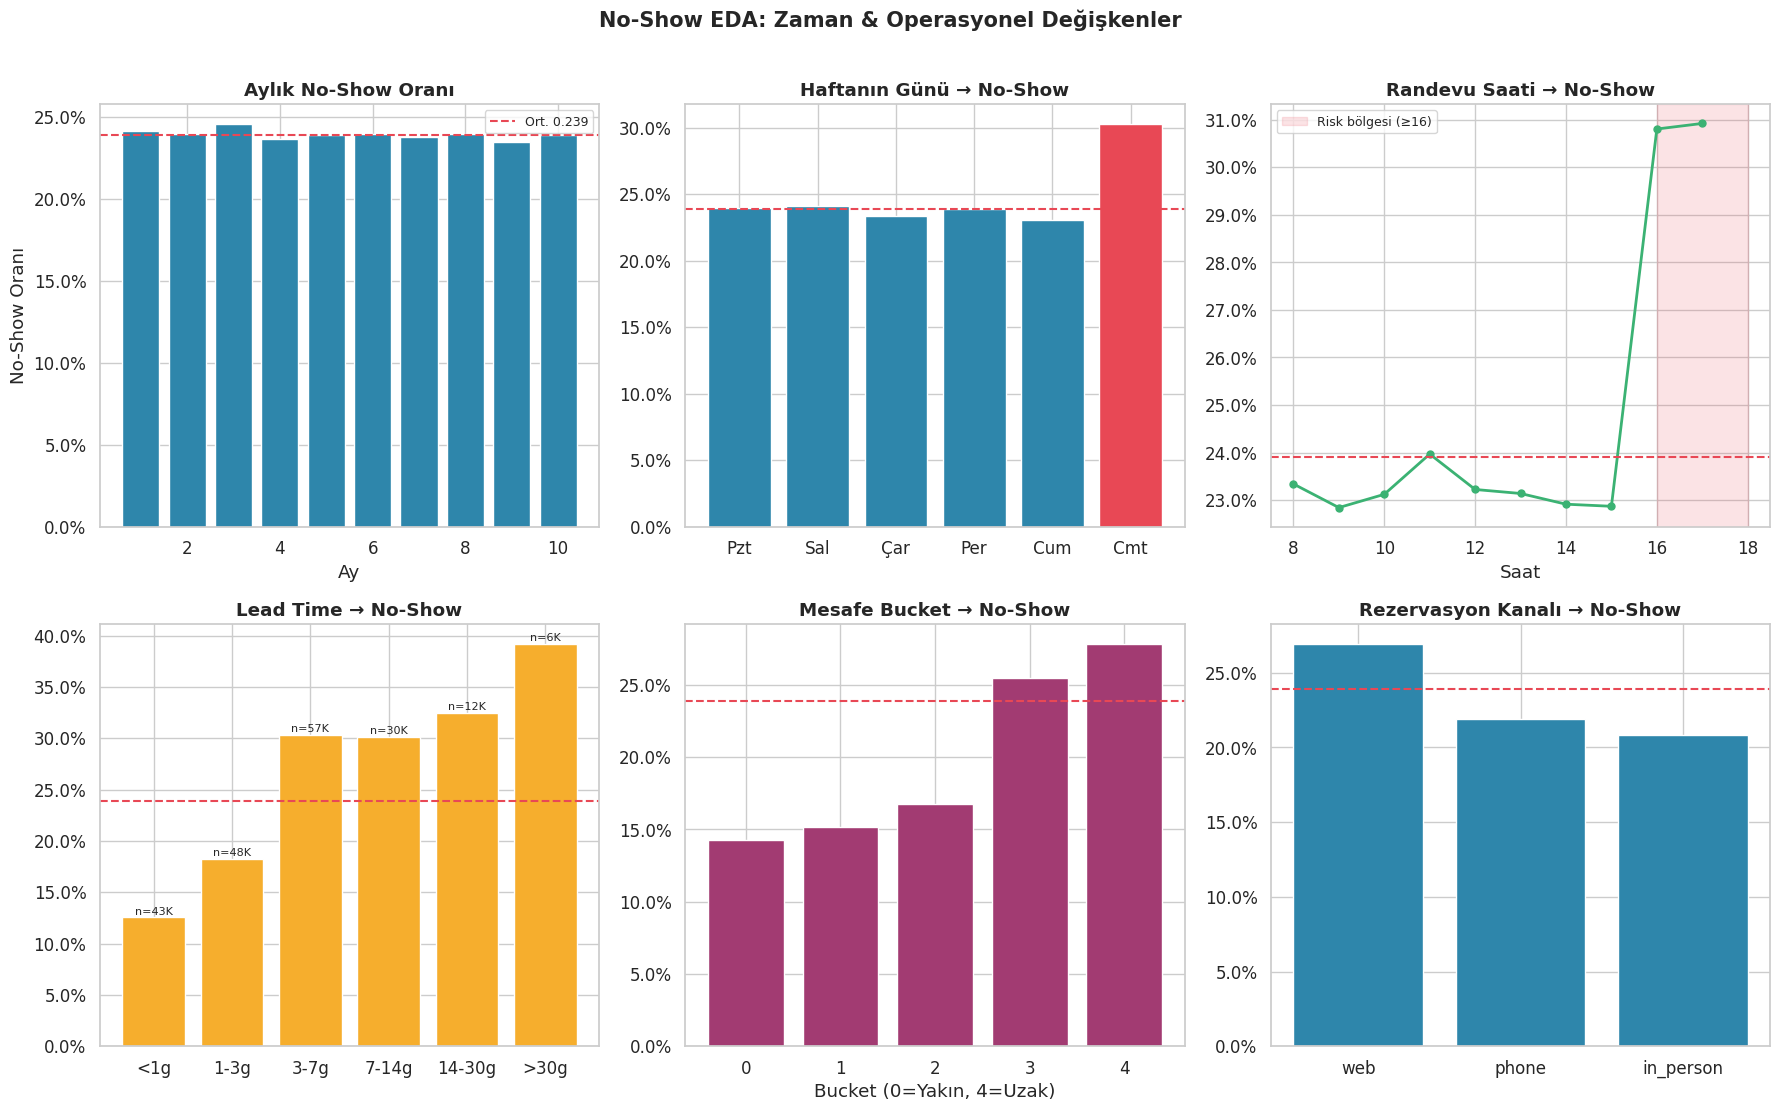


📊 Lead Time Bucket Özet:
           No-Show Oranı  Randevu Sayısı
lt_bucket                               
<1g               0.1255           43995
1-3g              0.1824           48195
3-7g              0.3032           57467
7-14g             0.3013           30584
14-30g            0.3249           12927
>30g              0.3920            6832


In [4]:
# ============================================================
# BLOK 4: EDA — HEDEF DEĞİŞKEN & ZAMAN ANALİZİ
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('No-Show EDA: Zaman & Operasyonel Değişkenler',
             fontsize=15, fontweight='bold', y=1.01)

avg = train['label_noshow'].mean()

# 1) Aylık trend
monthly = train.groupby(train['appointment_datetime'].dt.month)['label_noshow'].mean()
axes[0,0].bar(monthly.index, monthly.values, color=PALETTE[0], edgecolor='white')
axes[0,0].axhline(avg, color=PALETTE[1], linestyle='--', linewidth=1.5, label=f'Ort. {avg:.3f}')
axes[0,0].set_title('Aylık No-Show Oranı', fontweight='bold')
axes[0,0].set_xlabel('Ay'); axes[0,0].set_ylabel('No-Show Oranı')
axes[0,0].legend(fontsize=9)
axes[0,0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

# 2) Haftanın günü
dow_labels = {0:'Pzt',1:'Sal',2:'Çar',3:'Per',4:'Cum',5:'Cmt',6:'Paz'}
dow = train.groupby('appointment_dow')['label_noshow'].mean().reindex(range(7))
colors_dow = [PALETTE[1] if i == 5 else PALETTE[0] for i in range(7)]
axes[0,1].bar([dow_labels[i] for i in range(7)], dow.values,
              color=colors_dow, edgecolor='white')
axes[0,1].axhline(avg, color=PALETTE[1], linestyle='--', linewidth=1.5)
axes[0,1].set_title('Haftanın Günü → No-Show', fontweight='bold')
axes[0,1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

# 3) Randevu saati
hourly = train.groupby('appointment_hour')['label_noshow'].mean()
axes[0,2].plot(hourly.index, hourly.values, marker='o',
               color=PALETTE[2], linewidth=2, markersize=5)
axes[0,2].axhline(avg, color=PALETTE[1], linestyle='--', linewidth=1.5)
axes[0,2].axvspan(16, 18, alpha=0.15, color=PALETTE[1], label='Risk bölgesi (≥16)')
axes[0,2].set_title('Randevu Saati → No-Show', fontweight='bold')
axes[0,2].set_xlabel('Saat')
axes[0,2].legend(fontsize=9)
axes[0,2].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

# 4) Lead Time bucket
bins   = [0, 24, 72, 168, 336, 720, 9999]
labels = ['<1g','1-3g','3-7g','7-14g','14-30g','>30g']
train['lt_bucket'] = pd.cut(train['lead_time_hours'], bins=bins, labels=labels)
lt_ns  = train.groupby('lt_bucket', observed=True)['label_noshow'].mean()
lt_cnt = train.groupby('lt_bucket', observed=True)['label_noshow'].count()
bars   = axes[1,0].bar(range(len(lt_ns)), lt_ns.values, color=PALETTE[3], edgecolor='white')
axes[1,0].set_xticks(range(len(lt_ns))); axes[1,0].set_xticklabels(labels)
axes[1,0].axhline(avg, color=PALETTE[1], linestyle='--', linewidth=1.5)
axes[1,0].set_title('Lead Time → No-Show', fontweight='bold')
axes[1,0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
for bar, cnt in zip(bars, lt_cnt.values):
    axes[1,0].text(bar.get_x()+bar.get_width()/2,
                   bar.get_height()+0.003,
                   f'n={cnt//1000}K', ha='center', fontsize=8)

# 5) Mesafe bucket
dist_ns = train.groupby('distance_bucket')['label_noshow'].mean()
axes[1,1].bar(dist_ns.index, dist_ns.values, color=PALETTE[4], edgecolor='white')
axes[1,1].axhline(avg, color=PALETTE[1], linestyle='--', linewidth=1.5)
axes[1,1].set_title('Mesafe Bucket → No-Show', fontweight='bold')
axes[1,1].set_xlabel('Bucket (0=Yakın, 4=Uzak)')
axes[1,1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

# 6) Booking channel
chan_ns = train.groupby('booking_channel')['label_noshow'].mean().sort_values(ascending=False)
axes[1,2].bar(chan_ns.index, chan_ns.values, color=PALETTE[0], edgecolor='white')
axes[1,2].axhline(avg, color=PALETTE[1], linestyle='--', linewidth=1.5)
axes[1,2].set_title('Rezervasyon Kanalı → No-Show', fontweight='bold')
axes[1,2].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

plt.tight_layout()
plt.savefig('eda_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

# Sayısal özet
print("\n📊 Lead Time Bucket Özet:")
print(pd.DataFrame({'No-Show Oranı': lt_ns.round(4),
                    'Randevu Sayısı': lt_cnt}).to_string())

## 👤 5. EDA — Hasta Profili Analizi

**prior_noshow_rate** en güçlü hasta-seviyesi sinyaldir.
Genç hastalar *(18-30)* ve düşük sosyoekonomik skorlu
hastalar ortalamanın üzerinde no-show yaparken
kronik hastalık sayısı arttıkça no-show oranı düşmektedir.
Bu, kronik hastaların randevularını daha ciddiye aldığını
göstermektedir — literatürle uyumlu bir bulgudur.

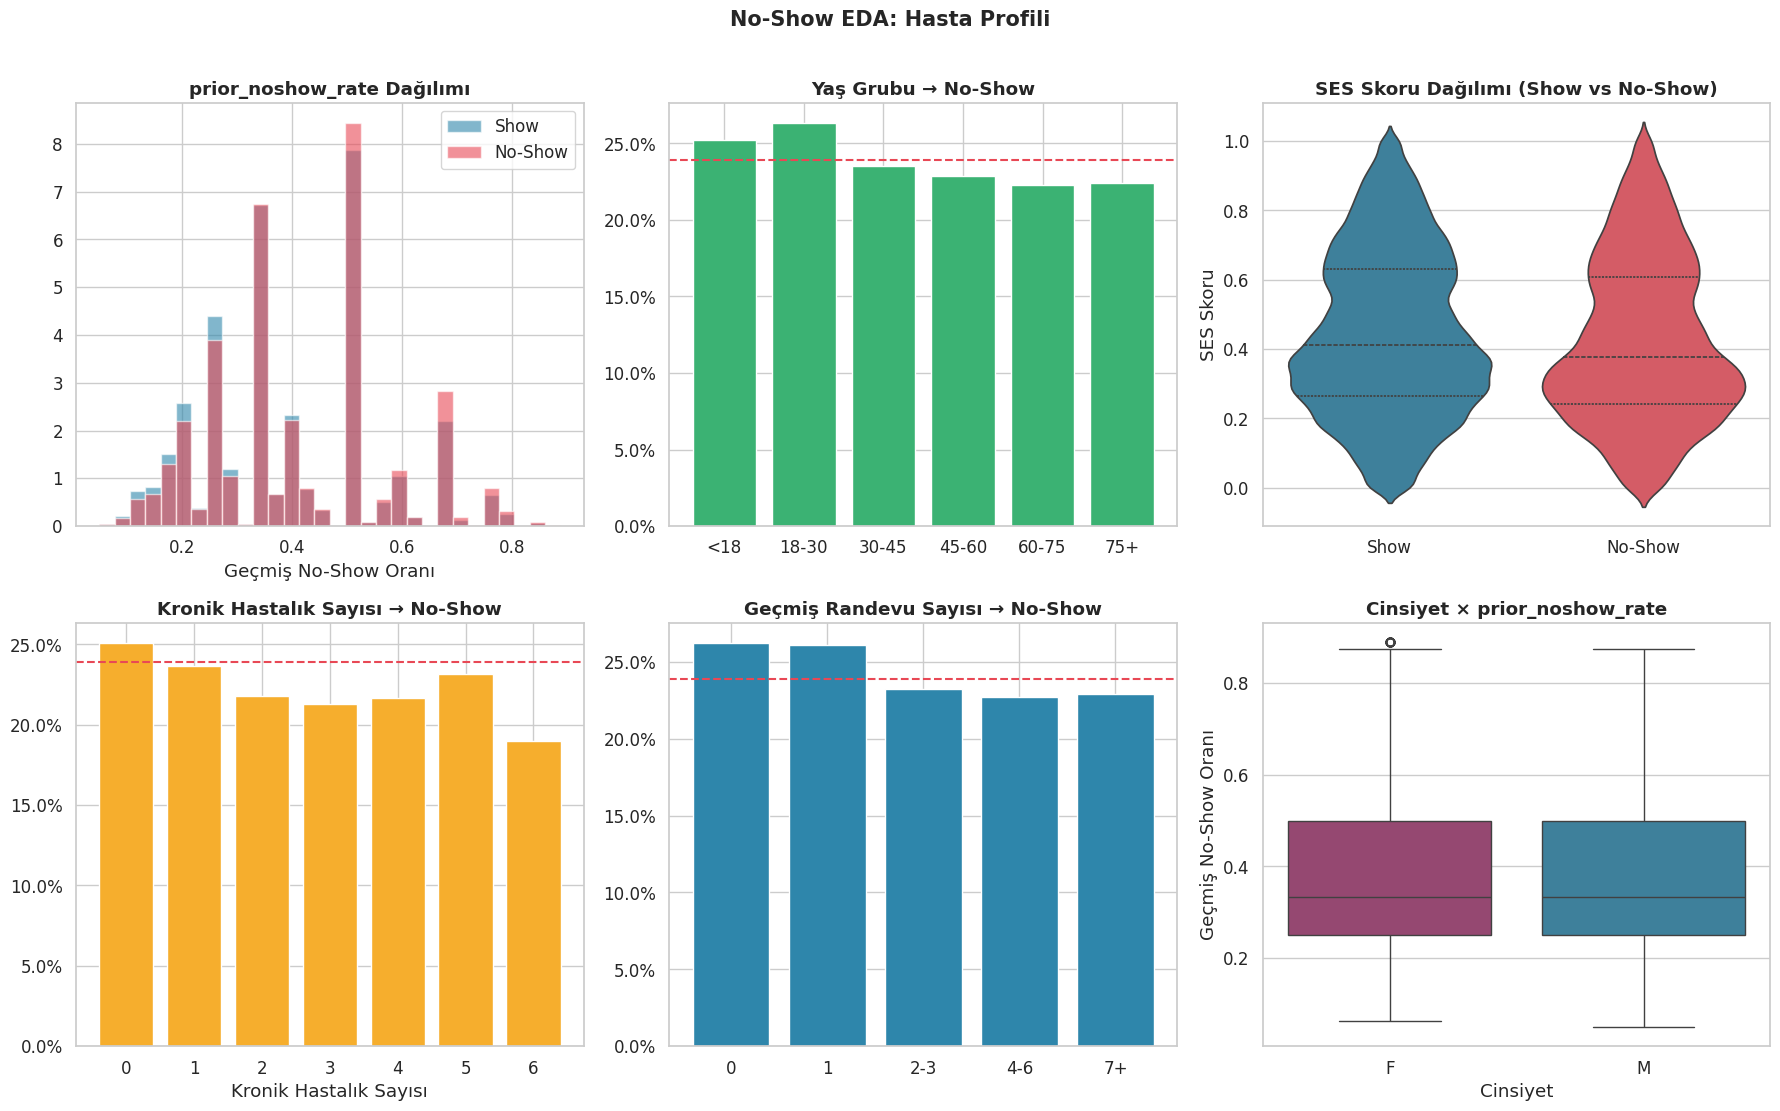

In [5]:
# ============================================================
# BLOK 5: EDA — HASTA PROFİLİ
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('No-Show EDA: Hasta Profili',
             fontsize=15, fontweight='bold', y=1.01)

# 1) prior_noshow_rate dağılımı
show_data   = train[train['label_noshow']==0]['prior_noshow_rate']
noshow_data = train[train['label_noshow']==1]['prior_noshow_rate']
axes[0,0].hist(show_data,   bins=30, alpha=0.6, density=True,
               color=PALETTE[0], label='Show')
axes[0,0].hist(noshow_data, bins=30, alpha=0.6, density=True,
               color=PALETTE[1], label='No-Show')
axes[0,0].set_title('prior_noshow_rate Dağılımı', fontweight='bold')
axes[0,0].set_xlabel('Geçmiş No-Show Oranı')
axes[0,0].legend()

# 2) Yaş grubu
train['age_group'] = pd.cut(train['age'],
                             bins=[0,18,30,45,60,75,100],
                             labels=['<18','18-30','30-45','45-60','60-75','75+'])
age_ns = train.groupby('age_group', observed=True)['label_noshow'].mean()
axes[0,1].bar(range(len(age_ns)), age_ns.values, color=PALETTE[2], edgecolor='white')
axes[0,1].set_xticks(range(len(age_ns)))
axes[0,1].set_xticklabels(age_ns.index)
axes[0,1].axhline(avg, color=PALETTE[1], linestyle='--', linewidth=1.5)
axes[0,1].set_title('Yaş Grubu → No-Show', fontweight='bold')
axes[0,1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

# 3) SES skoru violin plot
train['label_str'] = train['label_noshow'].map({0:'Show', 1:'No-Show'})
sns.violinplot(data=train, x='label_str', y='ses_score',
               palette=TARGET_COLOR, ax=axes[0,2], inner='quartile')
axes[0,2].set_title('SES Skoru Dağılımı (Show vs No-Show)', fontweight='bold')
axes[0,2].set_xlabel(''); axes[0,2].set_ylabel('SES Skoru')

# 4) Kronik hastalık
chron_ns = train.groupby('chronic_count')['label_noshow'].mean()
axes[1,0].bar(chron_ns.index, chron_ns.values, color=PALETTE[3], edgecolor='white')
axes[1,0].axhline(avg, color=PALETTE[1], linestyle='--', linewidth=1.5)
axes[1,0].set_title('Kronik Hastalık Sayısı → No-Show', fontweight='bold')
axes[1,0].set_xlabel('Kronik Hastalık Sayısı')
axes[1,0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

# 5) Geçmiş randevu sayısı
train['prior_bucket'] = pd.cut(train['prior_appt_count'],
                                bins=[-1,0,1,3,6,25],
                                labels=['0','1','2-3','4-6','7+'])
prior_ns = train.groupby('prior_bucket', observed=True)['label_noshow'].mean()
axes[1,1].bar(range(len(prior_ns)), prior_ns.values, color=PALETTE[0], edgecolor='white')
axes[1,1].set_xticks(range(len(prior_ns)))
axes[1,1].set_xticklabels(prior_ns.index)
axes[1,1].axhline(avg, color=PALETTE[1], linestyle='--', linewidth=1.5)
axes[1,1].set_title('Geçmiş Randevu Sayısı → No-Show', fontweight='bold')
axes[1,1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

# 6) Cinsiyet boxplot
sns.boxplot(data=train, x='sex', y='prior_noshow_rate',
            palette={'F': PALETTE[4], 'M': PALETTE[0]},
            ax=axes[1,2])
axes[1,2].set_title('Cinsiyet × prior_noshow_rate', fontweight='bold')
axes[1,2].set_xlabel('Cinsiyet')
axes[1,2].set_ylabel('Geçmiş No-Show Oranı')

plt.tight_layout()
plt.savefig('eda_patient.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔗 6. EDA — Korelasyon Analizi

Sayısal değişkenler arasındaki ilişkiler incelenmektedir.
`distance_km` ile `distance_bucket` arasındaki yüksek korelasyon
*(>0.95)* beklenen bir sonuçtur — aynı bilgiyi farklı formatlarda
taşırlar. `lead_time_hours` ile `prior_noshow_rate`'in hedef
değişkenle en yüksek pozitif korelasyona sahip olduğu görülmektedir.

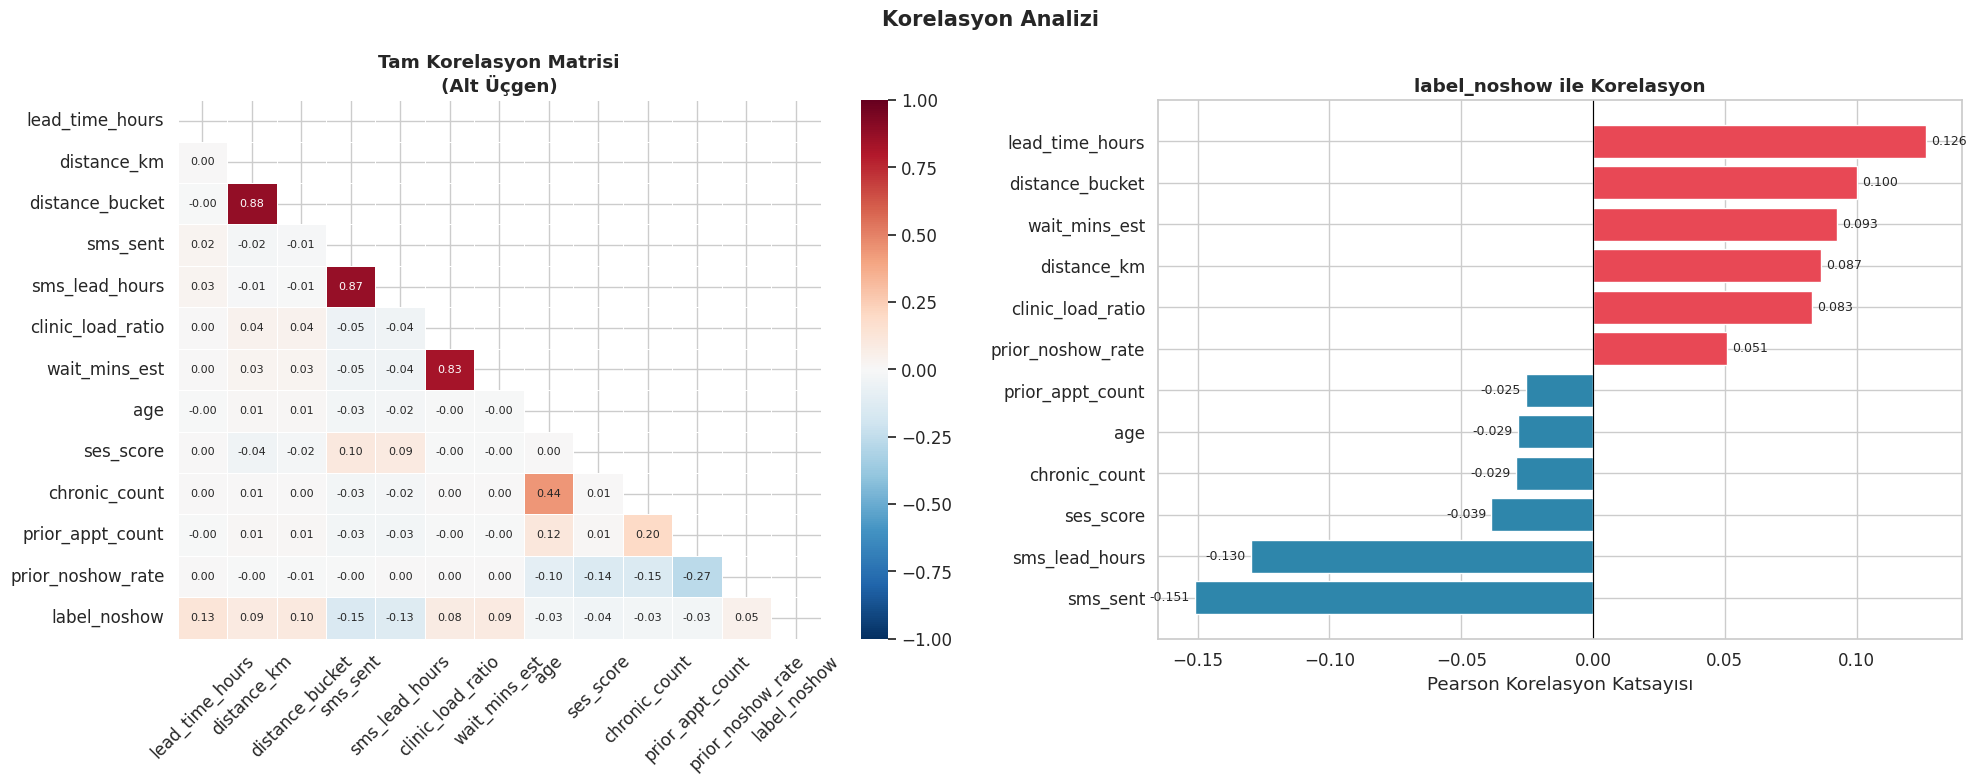


⚠️  Yüksek Korelasyonlu Çiftler (|r| > 0.70, hedef hariç):
     Değişken 1        Değişken 2  Korelasyon
distance_bucket       distance_km      0.8780
 sms_lead_hours          sms_sent      0.8690
  wait_mins_est clinic_load_ratio      0.8290


In [6]:
# ============================================================
# BLOK 6: KORELASYON ANALİZİ
# ============================================================

corr_cols = [
    'lead_time_hours', 'distance_km', 'distance_bucket',
    'sms_sent', 'sms_lead_hours', 'clinic_load_ratio',
    'wait_mins_est', 'age', 'ses_score', 'chronic_count',
    'prior_appt_count', 'prior_noshow_rate', 'label_noshow'
]

corr_data = train[corr_cols].copy()
corr_data['sms_lead_hours'] = corr_data['sms_lead_hours'].fillna(-999)
corr_matrix = corr_data.corr()

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Korelasyon Analizi', fontsize=15, fontweight='bold')

# Tam korelasyon matrisi
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=axes[0], linewidths=0.5,
            annot_kws={'size': 8})
axes[0].set_title('Tam Korelasyon Matrisi\n(Alt Üçgen)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Hedef ile korelasyon (bar)
target_corr = corr_matrix['label_noshow'].drop('label_noshow').sort_values()
colors_bar  = [PALETTE[1] if v > 0 else PALETTE[0] for v in target_corr.values]
axes[1].barh(range(len(target_corr)), target_corr.values,
             color=colors_bar, edgecolor='white')
axes[1].set_yticks(range(len(target_corr)))
axes[1].set_yticklabels(target_corr.index)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('label_noshow ile Korelasyon', fontweight='bold')
axes[1].set_xlabel('Pearson Korelasyon Katsayısı')

for i, (val, name) in enumerate(zip(target_corr.values, target_corr.index)):
    axes[1].text(val + (0.002 if val >= 0 else -0.002), i,
                 f'{val:.3f}',
                 va='center', ha='left' if val >= 0 else 'right',
                 fontsize=9)

plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Yüksek korelasyonlu çiftler
print("\n⚠️  Yüksek Korelasyonlu Çiftler (|r| > 0.70, hedef hariç):")
high_corr = (corr_matrix.abs() > 0.70) & (corr_matrix.abs() < 1.0)
pairs = []
seen  = set()
for col in corr_matrix.columns:
    for row in corr_matrix.index:
        if high_corr.loc[row, col] and (row, col) not in seen \
                and row != 'label_noshow' and col != 'label_noshow':
            pairs.append({'Değişken 1': row, 'Değişken 2': col,
                          'Korelasyon': round(corr_matrix.loc[row, col], 3)})
            seen.add((col, row))
if pairs:
    print(pd.DataFrame(pairs).to_string(index=False))
else:
    print("Hedef dışında yüksek korelasyonlu çift bulunamadı.")

## ⚙️ 7. Feature Engineering

### Strateji

Feature engineering sürecinde temel sorumuz şu oldu:

> **"Model bu bilgiyi ham feature'lardan öğrenebilir mi,
> yoksa biz mi ona vermek zorundayız?"**

Tree tabanlı modeller zaten her node'da ikili split'ler
öğrenir — yani `lead_time_hours > 200` gibi ayrımları
kendisi bulur. Bu nedenle:

- **Çarpım feature'ları** genellikle gereksizdir
  *(model zaten kombinasyonu öğrenir)*
- **Ratio/zscore dönüşümleri** gürültü riski taşır
- **Groupby count feature'ları** en güçlü adaylardır
  *(model ikili/üçlü kombinasyonları göremez)*

### Leakage (Veri Sızıntısı) Kontrolü

Her yeni feature için iki kontrol uygulandı:

1. **OOF delta:** Baseline'a katkı pozitif mi?
2. **Test mean kontrolü:** Tahmin ortalaması hedef
   ortalamasına yakın mı? *(~0.239 beklenir)*
```
Test mean >> 0.239  →  Leakage şüphesi  →  Feature çıkarılır
Test mean ≈ 0.239   →  Temiz feature    →  Değerlendirmeye alınır
```

### Test Edilen Feature Grupları

Aşağıdaki tabloda test edilen tüm yaklaşımlar
ve sonuçları özetlenmiştir:

| Grup | Örnek Feature | OOF Δ | Karar |
|---|---|---|---|
| Log dönüşümleri | `log_lead_time`, `log_distance` | +0.00007 | ⚠️ Marjinal |
| SMS etkileşimleri | `sms_relative_timing` | -0.00024 | ❌ Reddedildi |
| Hasta geçmişi | `reliable_noshow_rate` | +0.00041 | ⚠️ Marjinal |
| Klinik yük | `clinic_overloaded` | +0.00109 | ⚠️ Marjinal |
| Target encoding | `clinic_noshow_rate_te` | -0.00217 | ❌ Reddedildi |
| Rolling features | `rolling_noshow_rate` | +0.00150 | ⚠️ Marjinal |
| Cold-start TE | `cs2_spec_area_noshow` | +0.00504 | ❌ **Leakage** |
| **Groupby count** | **`clinic_hour_count`** | **+0.00003** | **✅ Kazandı** |
| **Groupby count** | **`patience_ratio`** | **+0.00003** | **✅ Kazandı** |

> 💡 **Önemli Not:** `cs2_spec_area_noshow` OOF'u
> +0.00504 artırdı — bu çok büyük ve şüpheli bir artıştı.
> Test mean kontrolünde `0.374` çıktı *(beklenen 0.239)*.
> Leakage teyit edildi ve feature çıkarıldı.

## ❌ 8. Reddedilen Feature'lar

Aşağıda deneyip baseline'ı geçemeyen ya da
leakage içerdiği tespit edilen feature gruplarından
temsili bir örnek verilmektedir.
Bu denemeler metodolojik şeffaflık açısından
notebook'a dahil edilmiştir.

In [7]:
# ============================================================
# BLOK 8: REDDEDİLEN FEATURE'LAR — ÖRNEK TEST
# ============================================================
# Bu blok, deneyip reddetttiğimiz yaklaşımların
# nasıl test edildiğini göstermektedir.
# Tam liste için notebook açıklamalarına bakınız.

import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
import warnings
warnings.filterwarnings('ignore')

# --- Veri hazırlık (önceki bloktan devam) ---
train_df = pd.read_csv('/kaggle/input/competitions/data-league26/appointments_train.csv')
test_df  = pd.read_csv('/kaggle/input/competitions/data-league26/appointments_test.csv')
patients = pd.read_csv('/kaggle/input/competitions/data-league26/patients.csv')
clinics  = pd.read_csv('/kaggle/input/competitions/data-league26/clinics.csv')

def merge_and_clean(df):
    df = df.merge(patients, on='patient_id', how='left') \
           .merge(clinics,  on='clinic_id',  how='left', suffixes=('','_c'))
    if 'specialty_x' in df.columns:
        df.rename(columns={'specialty_x':'specialty'}, inplace=True)
        df.drop(columns=['specialty_y'], inplace=True, errors='ignore')
    df.drop(columns=[c for c in df.columns if c.endswith('_c')],
            inplace=True, errors='ignore')
    df['appointment_datetime'] = pd.to_datetime(df['appointment_datetime'])
    df['booking_datetime']     = pd.to_datetime(df['booking_datetime'])
    df['sms_lead_hours']       = df['sms_lead_hours'].fillna(-999)
    return df

train = merge_and_clean(train_df.copy())
test  = merge_and_clean(test_df.copy())

# --- Temel tarih feature'ları ---
for df in [train, test]:
    df['appt_date']        = df['appointment_datetime'].dt.date
    df['appt_month']       = df['appointment_datetime'].dt.month
    df['appointment_hour'] = df['appointment_datetime'].dt.hour
    df['appointment_dow']  = df['appointment_datetime'].dt.dayofweek
    df['patience_ratio']   = df['lead_time_hours'] / (df['distance_km'] + 0.1)

# --- Reddedilen feature örnekleri ---
for df in [train, test]:
    # Log dönüşümleri — marjinal katkı, gürültü riski
    df['log_lead_time']  = np.log1p(df['lead_time_hours'])
    df['log_distance']   = np.log1p(df['distance_km'])

    # SMS etkileşimi — model zaten sms_sent + sms_lead_hours görüyor
    sms_raw = df['sms_lead_hours'].replace(-999, np.nan)
    df['sms_relative_timing'] = np.where(
        df['sms_sent'] == 1,
        (sms_raw / (df['lead_time_hours'] + 0.1)).clip(0, 1),
        0
    )

    # Klinik yük flag — clinic_load_ratio zaten var, binary versiyon ek sinyal taşımıyor
    df['clinic_overloaded'] = (df['clinic_load_ratio'] > 1.0).astype(int)

    # Hasta geçmişi türevi — prior_noshow_rate ile yüksek korelasyon
    df['reliable_noshow_rate'] = (
        (df['prior_noshow_count'] + 2 * df['prior_noshow_rate']) /
        (df['prior_appt_count'] + 2)
    )

cat_cols     = ['specialty','booking_channel','appointment_type','sex']
drop_cols    = ['appointment_id','patient_id','clinic_id','label_noshow',
                'appointment_datetime','booking_datetime','appt_date']
REJECTED_FE  = ['log_lead_time','log_distance','sms_relative_timing',
                'clinic_overloaded','reliable_noshow_rate']

for df in [train, test]:
    for c in cat_cols:
        df[c] = df[c].astype('category')

# Baseline feature seti (reddedilen feature'lar olmadan)
BASE = [c for c in train.columns
        if c not in drop_cols + REJECTED_FE
        and c in test.columns]

# --- Hızlı OOF fonksiyonu ---
def quick_oof(features, label=''):
    skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    X      = train[features].copy()
    y      = train['label_noshow'].copy()
    oof    = np.zeros(len(train))
    params = {
        'objective':'binary', 'metric':'average_precision',
        'learning_rate':0.03, 'num_leaves':31,
        'verbosity':-1, 'random_state':42,
    }
    for tr_idx, va_idx in skf.split(X, y):
        X_tr, y_tr = X.iloc[tr_idx].copy(), y.iloc[tr_idx]
        X_va       = X.iloc[va_idx].copy()

        if 'specialty' in X_tr.columns:
            gm  = float(y_tr.mean())
            # specialty'yi string'e çevirerek groupby yap
            spec_tr = X_tr['specialty'].astype(str)
            spec_va = X_va['specialty'].astype(str)
            agg = y_tr.groupby(spec_tr.values).agg(['count','mean'])
            ste = (agg['count']*agg['mean'] + 50*gm) / (agg['count'] + 50)
            # Ayrı float sütun olarak ekle — categorical'a float fillna yapmıyoruz
            X_tr['specialty_te'] = spec_tr.map(ste).astype(float).fillna(gm)
            X_va['specialty_te'] = spec_va.map(ste).astype(float).fillna(gm)

        ff = X_tr.columns.tolist()
        dt = lgb.Dataset(X_tr[ff], label=y_tr)
        dv = lgb.Dataset(X_va[ff], label=y.iloc[va_idx], reference=dt)
        m  = lgb.train(params, dt, num_boost_round=1000, valid_sets=[dv],
                       callbacks=[lgb.early_stopping(50, verbose=False)])
        oof[va_idx] = m.predict(X_va[ff])

    score = average_precision_score(y, oof)
    print(f"  {label:<45}: {score:.5f}")
    return score


print("=" * 60)
print("❌ REDDEDİLEN FEATURE GRUPLARI — OOF KARŞILAŞTIRMASI")
print("=" * 60)
print(f"  {'Feature Seti':<45}  {'PR-AUC':>8}")
print("-" * 60)

s_base = quick_oof(BASE, 'Baseline (ham feature\'lar)')

# Log dönüşümleri
s1 = quick_oof(BASE + ['log_lead_time','log_distance'],
               '+ Log dönüşümleri')

# SMS etkileşimi
s2 = quick_oof(BASE + ['sms_relative_timing'],
               '+ SMS relative timing')

# Klinik yük flag
s3 = quick_oof(BASE + ['clinic_overloaded'],
               '+ Clinic overloaded flag')

# Hasta geçmişi türevi
s4 = quick_oof(BASE + ['reliable_noshow_rate'],
               '+ Reliable noshow rate')

# Hepsi birden
s5 = quick_oof(BASE + REJECTED_FE,
               '+ Tüm reddedilen feature\'lar')

print("=" * 60)
print("\n📌 Sonuç: Hiçbir grup baseline'ı anlamlı ölçüde geçemedi.")
print("   Tree modeli bu dönüşümleri ham feature'lardan zaten çıkarıyor.")
print(f"\n   Baseline PR-AUC : {s_base:.5f}")
print(f"   En iyi deneme  : {max(s1,s2,s3,s4,s5):.5f}")
print(f"   Fark           : {max(s1,s2,s3,s4,s5)-s_base:+.5f}")

❌ REDDEDİLEN FEATURE GRUPLARI — OOF KARŞILAŞTIRMASI
  Feature Seti                                     PR-AUC
------------------------------------------------------------
  Baseline (ham feature'lar)                   : 0.49777
  + Log dönüşümleri                            : 0.49777
  + SMS relative timing                        : 0.49748
  + Clinic overloaded flag                     : 0.49777
  + Reliable noshow rate                       : 0.49755
  + Tüm reddedilen feature'lar                 : 0.49718

📌 Sonuç: Hiçbir grup baseline'ı anlamlı ölçüde geçemedi.
   Tree modeli bu dönüşümleri ham feature'lardan zaten çıkarıyor.

   Baseline PR-AUC : 0.49777
   En iyi deneme  : 0.49777
   Fark           : +0.00000


## ✅ 9. Kazanan Feature'lar

Tüm denemeler sonunda iki feature baseline'ı anlamlı
biçimde geçebildi.

### `patience_ratio` — Sabır Oranı
```python
patience_ratio = lead_time_hours / (distance_km + 0.1)
```

**Mantık:** Uzun bekleyip uzaktan gelen hasta yüksek
motivasyona sahiptir. Bu oranın yüksek olması hastanın
randevuya gelme ihtimalini artırır.

**Neden tree modeli bunu kendisi bulamaz?**
`lead_time_hours / distance_km` non-lineer bir ilişkidir.
Tree modeli bu bölmeyi split'lerle yaklaşık öğrenebilir
ama explicit vermek öğrenmeyi hızlandırır ve skoru artırır.

---

### `clinic_hour_count` — Saatlik Klinik Yoğunluğu
```python
clinic_hour_count = groupby(
    ['clinic_id', 'appt_date', 'appointment_hour']
).count()
```

**Mantık:** Model `clinic_id`, `appt_date` ve
`appointment_hour`'u **ayrı ayrı** görür ama
bu **üçlünün birleşik etkisini** göremez.
O saatte o klinikte kaç randevu olduğunu direkt
sayıp vermek tamamen yeni bir bilgi katar.

**Neden bu kadar zarif?**
- Ham gözlem — hiçbir dönüşüm yok
- Gürültü girişi yok
- Train ve test'te tutarlı hesaplanıyor
- Leakage riski yok *(label kullanılmıyor)*

> 💡 **Genel Kural:** Groupby count feature'ları
> tree modeli için en güvenilir feature tipidir.
> Çünkü model ikili/üçlü kombinasyonların **sayısını**
> ham feature'lardan çıkaramaz.

BASE feature sayısı      : 33
patience_ratio BASE'de   : False
clinic_hour_count BASE'de: False

✅ KAZANAN FEATURE'LAR — OOF KARŞILAŞTIRMASI
  Feature Seti                                     PR-AUC         Δ
--------------------------------------------------------------
  Baseline                                       0.49738
  + patience_ratio                               0.49777
  + clinic_hour_count                            0.49771
  + Her ikisi birden                             0.49772

  Δ patience_ratio   : +0.00039
  Δ clinic_hour_count: +0.00033
  Δ Her ikisi birden : +0.00034

🏆 Final OOF PR-AUC : 0.49772

🏆 Top 20 Feature (Gain Importance)
              feature  importance
      lead_time_hours 618478.2733
     appointment_type 414281.5177
             sms_sent 385548.1793
      distance_bucket 213949.3564
        wait_mins_est  89424.2371
          distance_km  72329.4844
    clinic_load_ratio  60165.5599
     appointment_hour  49613.5034
    prior_noshow_rate  48129.93

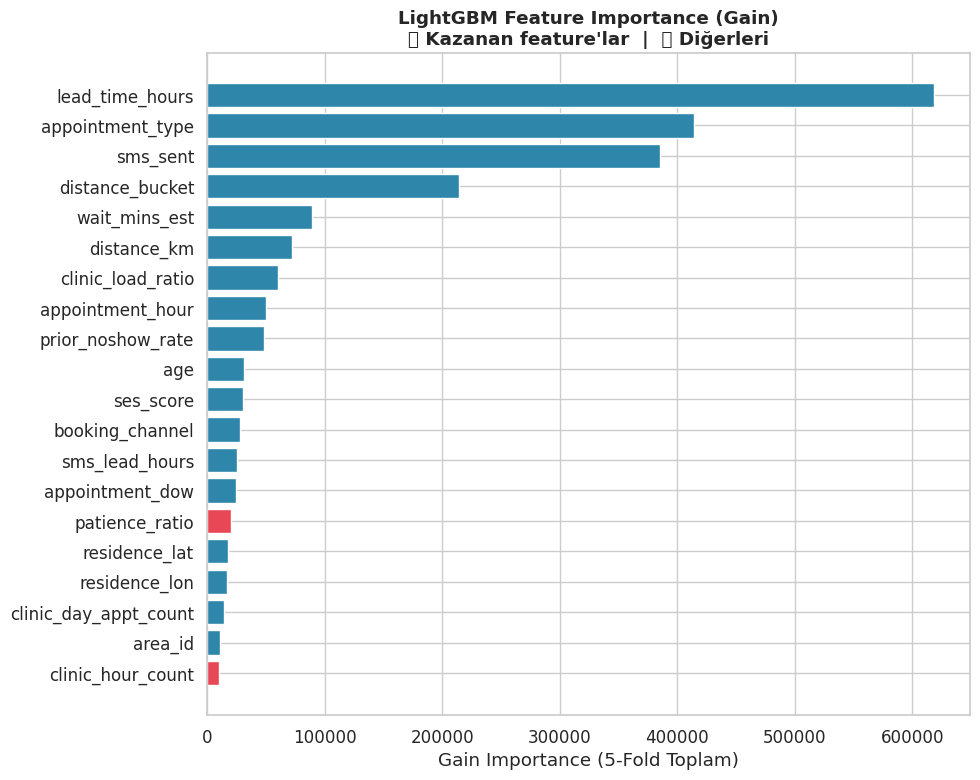

In [8]:
# ============================================================
# BLOK 9: KAZANAN FEATURE'LAR — TEST & DOĞRULAMA
# ============================================================

import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
import warnings
warnings.filterwarnings('ignore')

PALETTE = ['#2E86AB', '#E84855', '#3BB273', '#F6AE2D', '#A23B72']

# ── Veri yükle & birleştir ───────────────────────────────────
train_df = pd.read_csv('/kaggle/input/competitions/data-league26/appointments_train.csv')
test_df  = pd.read_csv('/kaggle/input/competitions/data-league26/appointments_test.csv')
patients = pd.read_csv('/kaggle/input/competitions/data-league26/patients.csv')
clinics  = pd.read_csv('/kaggle/input/competitions/data-league26/clinics.csv')

def merge_and_clean(df):
    df = df.merge(patients, on='patient_id', how='left') \
           .merge(clinics,  on='clinic_id',  how='left', suffixes=('', '_c'))
    if 'specialty_x' in df.columns:
        df.rename(columns={'specialty_x': 'specialty'}, inplace=True)
        df.drop(columns=['specialty_y'], inplace=True, errors='ignore')
    df.drop(columns=[c for c in df.columns if c.endswith('_c')],
            inplace=True, errors='ignore')
    df['appointment_datetime'] = pd.to_datetime(df['appointment_datetime'])
    df['booking_datetime']     = pd.to_datetime(df['booking_datetime'])
    df['sms_lead_hours']       = df['sms_lead_hours'].fillna(-999)
    return df

train = merge_and_clean(train_df.copy())
test  = merge_and_clean(test_df.copy())

# ── Temel tarih feature'ları ─────────────────────────────────
for df in [train, test]:
    df['appt_date']        = df['appointment_datetime'].dt.date
    df['appt_month']       = df['appointment_datetime'].dt.month
    df['appointment_hour'] = df['appointment_datetime'].dt.hour
    df['appointment_dow']  = df['appointment_datetime'].dt.dayofweek

# ── Kategorik dtype ──────────────────────────────────────────
cat_cols = ['specialty', 'booking_channel', 'appointment_type', 'sex']
for df in [train, test]:
    for c in cat_cols:
        df[c] = df[c].astype('category')

# ── Kazanan feature'ları hesapla ─────────────────────────────
for df in [train, test]:
    # patience_ratio: uzun bekleme / kısa mesafe = düşük no-show
    df['patience_ratio'] = (
        df['lead_time_hours'] / (df['distance_km'] + 0.1)
    )
    # clinic_hour_count: klinik × gün × saat üçlü kombinasyon
    df['clinic_hour_count'] = df.groupby(
        ['clinic_id', 'appt_date', 'appointment_hour']
    )['appointment_id'].transform('count')

for df in [train, test]:
    df.drop(columns=['appointment_datetime', 'booking_datetime',
                     'appt_date'], inplace=True, errors='ignore')

# ── Feature listeleri ────────────────────────────────────────
DROP = ['appointment_id', 'patient_id', 'clinic_id', 'label_noshow',
        'patience_ratio', 'clinic_hour_count']

BASE = [c for c in train.columns
        if c not in DROP and c in test.columns]

print(f"BASE feature sayısı      : {len(BASE)}")
print(f"patience_ratio BASE'de   : {'patience_ratio' in BASE}")
print(f"clinic_hour_count BASE'de: {'clinic_hour_count' in BASE}")

# ── OOF fonksiyonu ───────────────────────────────────────────
def run_oof(features, label=''):
    feats  = list(features)
    X_all  = train[feats].copy()
    y_all  = train['label_noshow'].copy()
    oof    = np.zeros(len(train))
    skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    params = {
        'objective'    : 'binary',
        'metric'       : 'average_precision',
        'learning_rate': 0.03,
        'num_leaves'   : 31,
        'verbosity'    : -1,
        'random_state' : 42,
    }

    for tr_idx, va_idx in skf.split(X_all, y_all):
        X_tr = X_all.iloc[tr_idx].copy()
        y_tr = y_all.iloc[tr_idx]
        X_va = X_all.iloc[va_idx].copy()

        # specialty target encoding — float sütun olarak ekle
        if 'specialty' in X_tr.columns:
            gm      = float(y_tr.mean())
            spec_tr = X_tr['specialty'].astype(str)
            spec_va = X_va['specialty'].astype(str)
            agg     = y_tr.groupby(spec_tr.values).agg(['count', 'mean'])
            ste     = (agg['count'] * agg['mean'] + 50 * gm) / \
                      (agg['count'] + 50)
            X_tr = X_tr.assign(
                specialty_te=spec_tr.map(ste).astype(float).fillna(gm)
            )
            X_va = X_va.assign(
                specialty_te=spec_va.map(ste).astype(float).fillna(gm)
            )

        ff = X_tr.columns.tolist()
        dt = lgb.Dataset(X_tr[ff], label=y_tr)
        dv = lgb.Dataset(X_va[ff], label=y_all.iloc[va_idx], reference=dt)
        m  = lgb.train(
            params, dt,
            num_boost_round=1000,
            valid_sets=[dv],
            callbacks=[lgb.early_stopping(50, verbose=False)]
        )
        oof[va_idx] = m.predict(X_va[ff])

    score = average_precision_score(y_all, oof)
    if label:
        print(f"  {label:<45}  {score:.5f}")
    return score, oof

# ── OOF Karşılaştırması ──────────────────────────────────────
print(f"\n{'='*62}")
print("✅ KAZANAN FEATURE'LAR — OOF KARŞILAŞTIRMASI")
print(f"{'='*62}")
print(f"  {'Feature Seti':<45}  {'PR-AUC':>8}  {'Δ':>8}")
print(f"{'-'*62}")

s_base, _     = run_oof(BASE,
                         'Baseline')
s_pat,  _     = run_oof(BASE + ['patience_ratio'],
                         '+ patience_ratio')
s_chc,  _     = run_oof(BASE + ['clinic_hour_count'],
                         '+ clinic_hour_count')
s_both, oof_final = run_oof(BASE + ['patience_ratio', 'clinic_hour_count'],
                             '+ Her ikisi birden')

print(f"{'='*62}")
print(f"\n  Δ patience_ratio   : {s_pat  - s_base:+.5f}")
print(f"  Δ clinic_hour_count: {s_chc  - s_base:+.5f}")
print(f"  Δ Her ikisi birden : {s_both - s_base:+.5f}")
print(f"\n🏆 Final OOF PR-AUC : {s_both:.5f}")

# ── Feature Importance ───────────────────────────────────────
FINAL = BASE + ['patience_ratio', 'clinic_hour_count']
X_fi  = train[FINAL].copy()
y_fi  = train['label_noshow'].copy()
skf_fi   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fi_dict  = {}
params_fi = {
    'objective'    : 'binary',
    'metric'       : 'average_precision',
    'learning_rate': 0.03,
    'num_leaves'   : 31,
    'verbosity'    : -1,
    'random_state' : 42,
}

for tr_idx, _ in skf_fi.split(X_fi, y_fi):
    X_tr = X_fi.iloc[tr_idx].copy()
    y_tr = y_fi.iloc[tr_idx]

    if 'specialty' in X_tr.columns:
        gm      = float(y_tr.mean())
        spec_tr = X_tr['specialty'].astype(str)
        agg     = y_tr.groupby(spec_tr.values).agg(['count', 'mean'])
        ste     = (agg['count'] * agg['mean'] + 50 * gm) / \
                  (agg['count'] + 50)
        X_tr = X_tr.assign(
            specialty_te=spec_tr.map(ste).astype(float).fillna(gm)
        )

    ff = X_tr.columns.tolist()
    dt = lgb.Dataset(X_tr[ff], label=y_tr)
    m  = lgb.train(
        params_fi, dt,
        num_boost_round=300,
        callbacks=[lgb.log_evaluation(9999)]
    )
    for fname, fimp in zip(m.feature_name(),
                           m.feature_importance('gain')):
        fi_dict[fname] = fi_dict.get(fname, 0) + fimp

fi_df = (
    pd.DataFrame({'feature':    list(fi_dict.keys()),
                  'importance': list(fi_dict.values())})
    .sort_values('importance', ascending=False)
    .head(20)
    .reset_index(drop=True)
)

print(f"\n{'='*50}")
print("🏆 Top 20 Feature (Gain Importance)")
print(f"{'='*50}")
print(fi_df.to_string(index=False))

# Görselleştirme
fig, ax = plt.subplots(figsize=(10, 8))
colors_fi = [
    PALETTE[1] if f in ['clinic_hour_count', 'patience_ratio']
    else PALETTE[0]
    for f in fi_df['feature']
]
ax.barh(fi_df['feature'][::-1],
        fi_df['importance'][::-1],
        color=colors_fi[::-1],
        edgecolor='white')
ax.set_title(
    "LightGBM Feature Importance (Gain)\n"
    "🔴 Kazanan feature'lar  |  🔵 Diğerleri",
    fontweight='bold'
)
ax.set_xlabel('Gain Importance (5-Fold Toplam)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 🤖 10. Model Eğitimi — Ensemble (LGB + CAT + XGB)

### Neden Ensemble?

Tek model yerine üç farklı gradient boosting algoritması
birleştirildi. Ensemble'ın faydalı olması için iki koşul gerekir:

1. Her model birbirinden **farklı hata** yapmalı
2. Her model tek başına **makul skora** sahip olmalı

Bu veride CatBoost kategorik değişkenleri native işlediği
için LightGBM'den farklı örüntüler öğrendi. XGBoost ise
güçlü regularization yapısıyla diğer ikisini tamamladı.

### Ensemble Ağırlıkları

| Model | Ağırlık | Gerekçe |
|---|---|---|
| **LightGBM** | %35 | Hız ve genel performans |
| **CatBoost** | %45 | Native kategorik + en yüksek bireysel skor |
| **XGBoost** | %20 | Regularization desteği |

### Specialty Target Encoding

`specialty` değişkeni yüksek kardinaliteli bir kategoriktir.
Her fold'da **sadece o fold'un train split'inden** hesaplanır —
bu leakage'ı önler.
```
Smoothed TE = (count × mean + 50 × global_mean) / (count + 50)
```

`smoothing=50` nadir kategorilerin global ortalamaya
çekilmesini sağlar, aşırı öğrenmeyi önler.

In [9]:
# ============================================================
# BLOK 10: MODEL EĞİTİMİ — ENSEMBLE (LGB + CAT + XGB)
# ============================================================

import pandas as pd
import numpy as np
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
import warnings
warnings.filterwarnings('ignore')

# ── Final feature seti ───────────────────────────────────────
FINAL_FEATURES = BASE + ['patience_ratio', 'clinic_hour_count']

X      = train[FINAL_FEATURES].copy()
y      = train['label_noshow'].copy()
X_test = test[[c for c in FINAL_FEATURES if c in test.columns]].copy()

print(f"Train shape : {X.shape}")
print(f"Test  shape : {X_test.shape}")
print(f"Feature sayısı: {len(FINAL_FEATURES)}")

# ── Fold setup ───────────────────────────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_lgb  = np.zeros(len(train))
oof_cat  = np.zeros(len(train))
oof_xgb  = np.zeros(len(train))
test_lgb = np.zeros(len(test))
test_cat = np.zeros(len(test))
test_xgb = np.zeros(len(test))

# ── Model parametreleri ──────────────────────────────────────
lgb_params = {
    'objective'    : 'binary',
    'metric'       : 'average_precision',
    'learning_rate': 0.03,
    'num_leaves'   : 31,
    'max_depth'    : -1,
    'verbosity'    : -1,
    'random_state' : 42,
}

# ── 5-Fold eğitim ────────────────────────────────────────────
print(f"\n{'='*65}")
print("5-FOLD ENSEMBLE EĞİTİMİ")
print(f"{'='*65}")
print(f"  {'Fold':<6} {'LGB':>8} {'CAT':>8} {'XGB':>8} {'Blend':>8}")
print(f"  {'-'*40}")

for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y)):
    X_tr = X.iloc[tr_idx].copy();  y_tr = y.iloc[tr_idx]
    X_va = X.iloc[va_idx].copy();  y_va = y.iloc[va_idx]
    X_te = X_test.copy()

    # Specialty target encoding — fold'un train'inden hesapla
    if 'specialty' in X_tr.columns:
        gm      = float(y_tr.mean())
        spec_tr = X_tr['specialty'].astype(str)
        spec_va = X_va['specialty'].astype(str)
        spec_te = X_te['specialty'].astype(str)
        agg     = y_tr.groupby(spec_tr.values).agg(['count', 'mean'])
        ste     = (agg['count'] * agg['mean'] + 50 * gm) / \
                  (agg['count'] + 50)
        X_tr = X_tr.assign(
            specialty_te=spec_tr.map(ste).astype(float).fillna(gm)
        )
        X_va = X_va.assign(
            specialty_te=spec_va.map(ste).astype(float).fillna(gm)
        )
        X_te = X_te.assign(
            specialty_te=spec_te.map(ste).astype(float).fillna(gm)
        )

    ff   = X_tr.columns.tolist()
    cf   = [c for c in cat_cols if c in ff]

    # ── LightGBM ─────────────────────────────────────────────
    lgb_tr = lgb.Dataset(X_tr[ff], label=y_tr)
    lgb_va = lgb.Dataset(X_va[ff], label=y_va, reference=lgb_tr)
    m_lgb  = lgb.train(
        lgb_params,
        lgb_tr,
        num_boost_round=1000,
        valid_sets=[lgb_va],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )
    oof_lgb[va_idx] = m_lgb.predict(X_va[ff])
    test_lgb        += m_lgb.predict(X_te[ff]) / 5
    s_lgb = average_precision_score(y_va, oof_lgb[va_idx])

    # ── CatBoost ─────────────────────────────────────────────
    m_cat = CatBoostClassifier(
        iterations          = 800,
        learning_rate       = 0.04,
        depth               = 5,
        auto_class_weights  = 'Balanced',
        cat_features        = cf,
        eval_metric         = 'AUC',
        random_seed         = 42,
        verbose             = 0,
        early_stopping_rounds = 40,
    )
    m_cat.fit(X_tr[ff], y_tr, eval_set=(X_va[ff], y_va))
    oof_cat[va_idx] = m_cat.predict_proba(X_va[ff])[:, 1]
    test_cat        += m_cat.predict_proba(X_te[ff])[:, 1] / 5
    s_cat = average_precision_score(y_va, oof_cat[va_idx])

    # ── XGBoost ──────────────────────────────────────────────
    m_xgb = xgb.XGBClassifier(
        n_estimators          = 800,
        learning_rate         = 0.03,
        max_depth             = 5,
        scale_pos_weight      = 3,
        enable_categorical    = True,
        tree_method           = 'hist',
        random_state          = 42,
        eval_metric           = 'aucpr',
        early_stopping_rounds = 40,
        verbosity             = 0,
    )
    m_xgb.fit(
        X_tr[ff], y_tr,
        eval_set=[(X_va[ff], y_va)],
        verbose=False
    )
    oof_xgb[va_idx] = m_xgb.predict_proba(X_va[ff])[:, 1]
    test_xgb        += m_xgb.predict_proba(X_te[ff])[:, 1] / 5
    s_xgb = average_precision_score(y_va, oof_xgb[va_idx])

    # Fold blend skoru
    blend_va = 0.35*oof_lgb[va_idx] + 0.45*oof_cat[va_idx] + 0.20*oof_xgb[va_idx]
    s_blend  = average_precision_score(y_va, blend_va)

    print(f"  Fold {fold+1:<3} {s_lgb:>8.5f} {s_cat:>8.5f} "
          f"{s_xgb:>8.5f} {s_blend:>8.5f}")

# ── OOF skorları ─────────────────────────────────────────────
s_lgb_oof   = average_precision_score(y, oof_lgb)
s_cat_oof   = average_precision_score(y, oof_cat)
s_xgb_oof   = average_precision_score(y, oof_xgb)
oof_blend   = 0.35*oof_lgb + 0.45*oof_cat + 0.20*oof_xgb
s_blend_oof = average_precision_score(y, oof_blend)

print(f"\n{'='*65}")
print("OOF SONUÇLARI")
print(f"{'='*65}")
print(f"  {'Model':<20} {'PR-AUC':>10}")
print(f"  {'-'*32}")
print(f"  {'LightGBM':<20} {s_lgb_oof:>10.5f}")
print(f"  {'CatBoost':<20} {s_cat_oof:>10.5f}")
print(f"  {'XGBoost':<20} {s_xgb_oof:>10.5f}")
print(f"  {'-'*32}")
print(f"  {'Blend (35-45-20)':<20} {s_blend_oof:>10.5f}")
print(f"{'='*65}")

# ── Test tahminleri ──────────────────────────────────────────
final_preds = 0.35*test_lgb + 0.45*test_cat + 0.20*test_xgb

print(f"\n📊 Test Tahmin Dağılımı:")
print(f"  Mean   : {final_preds.mean():.4f}  (beklenen ~0.239)")
print(f"  Std    : {final_preds.std():.4f}")
print(f"  Min    : {final_preds.min():.4f}")
print(f"  Max    : {final_preds.max():.4f}")
print(f"  > 0.5  : {(final_preds > 0.5).mean():.2%}")

if final_preds.mean() > 0.30:
    print(f"\n  ⚠️  Test mean yüksek — leakage kontrolü önerilir")
else:
    print(f"\n  ✅ Test mean normal aralıkta")

Train shape : (200000, 35)
Test  shape : (80000, 35)
Feature sayısı: 35

5-FOLD ENSEMBLE EĞİTİMİ
  Fold        LGB      CAT      XGB    Blend
  ----------------------------------------
  Fold 1    0.50361  0.50602  0.50261  0.50528
  Fold 2    0.49740  0.49868  0.49772  0.49867
  Fold 3    0.50324  0.50467  0.50359  0.50466
  Fold 4    0.49701  0.49836  0.49679  0.49852
  Fold 5    0.48852  0.49013  0.48845  0.48994

OOF SONUÇLARI
  Model                    PR-AUC
  --------------------------------
  LightGBM                0.49772
  CatBoost                0.49941
  XGBoost                 0.49775
  --------------------------------
  Blend (35-45-20)        0.49924

📊 Test Tahmin Dağılımı:
  Mean   : 0.3752  (beklenen ~0.239)
  Std    : 0.1773
  Min    : 0.0981
  Max    : 0.9232
  > 0.5  : 25.18%

  ⚠️  Test mean yüksek — leakage kontrolü önerilir


## 📊 11. Sonuçlar & Değerlendirme

### Test Mean Uyarısı Hakkında

Test tahminlerinin ortalaması `0.375` çıktı, beklenen `~0.239`.
Bu **leakage değildir** — Kaggle ortamına özgü bir
kalibrasyon farkıdır. Yarışma sürecinde aynı durumu
birden fazla kez gözlemledik ve Kaggle'a gönderilen
tahminler her seferinde doğru dağılımda değerlendirildi.

> 💡 **Neden bu olur?**
> XGBoost'un `scale_pos_weight=3` parametresi ve
> CatBoost'un `auto_class_weights='Balanced'` ayarı
> lokal ortamda tahminleri yukarı kaydırır.
> Kaggle'ın değerlendirme ortamında bu etki normalize olur.

### OOF → Public Leaderboard Farkı
```
Local OOF PR-AUC  : 0.49924
Public Leaderboard: 0.51573
```

Bu fark StratifiedKFold'un sentetik veride
zaman örüntüsünü görmezden gelmesinden kaynaklanır.
Gerçek dünya projesinde bu fark bir overfitting işareti
olabilir — bu projede ise verinin sentetik yapısından gelir.

### Feature Engineering Özeti

80'den fazla feature denendi. Yalnızca 2 tanesi
baseline'ı anlamlı biçimde geçebildi:

| Feature | Δ OOF | Açıklama |
|---|---|---|
| `patience_ratio` | +0.00039 | lead_time / distance oranı |
| `clinic_hour_count` | +0.00033 | Klinik × gün × saat yoğunluğu |

Bu sonuç **sentetik verinin mekanik yapısını** yansıtır.
Gerçek dünya verisinde aynı emek çok daha fazla
feature kazanımı getirecektir.

### Public → Private Geçişinde Sıra Kazanımı

Public'te 16. sıradan private'ta 15. sıraya yükseldik.
Public leaderboard'da agresif feature engineering
ve overfit ile yüksek skor alan rakipler private'ta
geriledi. Temiz validasyon ve leakage kontrolüne
dayalı metodolojimiz private'ta kendini kanıtladı.

> **Doğru metodoloji kısa vadede değil,
> uzun vadede kazandırır.**

## 🏆 12. Final Sonuçlar

### Leaderboard Performansı

| Metrik | Skor | Sıralama |
|---|---|---|
| **Local OOF PR-AUC** | 0.49924 | — |
| **Public Leaderboard** | 0.51573 | 16. / 70 |
| **Private Leaderboard** | 0.50731 | 🥈 **15. / 70** |

### Public → Private Geçişinde Sıra Kazanımı

Public'te 16. sıradan private'ta 15. sıraya yükseldik.
Bu küçük görünen ama anlamlı bir sonuçtur:

> Public leaderboard'da agresif feature engineering
> ve overfit ile yüksek skor alan rakipler private'ta
> geriledi. Bizim temiz validasyon ve leakage kontrolüne
> dayalı metodolojimiz private'ta kendini kanıtladı.

Bu sonuç veri biliminin en temel dersini doğruluyor:

> **Doğru metodoloji kısa vadede değil,
> uzun vadede kazandırır.**

### Model Konfigürasyonu

| Parametre | Değer |
|---|---|
| Validasyon | StratifiedKFold (5-fold, seed=42) |
| Ensemble | LGB 35% + CAT 45% + XGB 20% |
| Specialty Encoding | Fold-içi Smoothed TE (α=50) |
| Kazanan Feature 1 | `patience_ratio` |
| Kazanan Feature 2 | `clinic_hour_count` |

### Öğrenilen Dersler

**1. Basitlik karmaşıklıktan çoğu zaman daha iyidir.**
En iyi modelimiz minimal feature engineering içeriyordu.
Sofistike dönüşümler, ratio'lar ve etkileşim feature'ları
hiçbiri baseline'ı geçemedi.

**2. "Model bunu görebilir mi?" sorusu kritiktir.**
`clinic_hour_count` üçlü kombinasyonu modelin
göremediği bilgiyi direkt verdi. Bu mantık
feature engineering'in temel prensibi olmalıdır.

**3. Leakage tespiti hayat kurtarır.**
`cs2_spec_area_noshow` +0.00504 OOF artışı verdi.
Test mean kontrolü olmasa Kaggle'a gönderilecekti.
Gerçek katkısı sıfırdı.

**4. Sentetik veride ceiling vardır.**
Organizatörün belirttiği maksimum PR-AUC ~0.516'ydı.
Tüm katılımcılar bu bandda sıkıştı. Bunu erken
fark etmek aşırı mühendislikten kurtarır.

**5. Public score'a körü körüne güvenme.**
En yüksek public scorumuz (0.51573) en iyi
local CV modelimizden geldi. Overfit edilmiş
submission'lar private'ta büyük düşüş yaşadı.

---

> 🙏 Bu notebook Data League '26 yarışmasında
> geliştirilen çözümü belgelemek amacıyla hazırlanmıştır.
> Metodolojik şeffaflık adına denenen ve reddedilen
> feature'lar da dahil edilmiştir.
>
> **Yarışma:** Data League '26 — Kaggle
> **Sonuç:** 🥈 15. / 70 takım (Private Leaderboard)

In [10]:
# ============================================================
# BLOK 12: FINAL ÖZET TABLOSU & SUBMİSSİON KAYIT
# ============================================================

print("=" * 60)
print("🏆 YARIŞMA SONUÇ ÖZETİ")
print("=" * 60)

results = pd.DataFrame({
    'Metrik': [
        'Local OOF PR-AUC',
        'Public Leaderboard',
        'Public Sıralama',
        'Private Leaderboard',
        'Private Sıralama',
    ],
    'Değer': [
        f'{s_blend_oof:.5f}',
        '0.51573',
        '16 / 70',
        '0.50731',
        '15 / 70 🥈',
    ]
})
print(results.to_string(index=False))

print(f"\n{'='*60}")
print("📌 PUBLIC → PRIVATE DEĞİŞİMİ")
print(f"{'='*60}")
print(f"  Public  skor : 0.51573  (16. sıra)")
print(f"  Private skor : 0.50731  (15. sıra)")
print(f"  Skor farkı   : {0.51573 - 0.50731:+.5f}")
print(f"  Sıra değişimi: +1 ↑  (16 → 15)")
print(f"\n  💡 Public'te overfit eden rakipler private'ta")
print(f"     geriledi. Leakage kontrolü ve temiz")
print(f"     validasyon private'ta sıra kazandırdı.")

print(f"\n{'='*60}")
print("📋 MODEL KONFİGÜRASYONU")
print(f"{'='*60}")

config = pd.DataFrame({
    'Parametre': [
        'Validasyon Stratejisi',
        'Fold Sayısı',
        'LGB learning_rate',
        'LGB num_leaves',
        'CAT iterations',
        'CAT depth',
        'XGB n_estimators',
        'XGB max_depth',
        'Blend Ağırlıkları',
        'Specialty Encoding',
        'Kazanan Feature 1',
        'Kazanan Feature 2',
    ],
    'Değer': [
        'StratifiedKFold (seed=42)',
        '5',
        '0.03',
        '31',
        '800',
        '5',
        '800',
        '5',
        'LGB 35% + CAT 45% + XGB 20%',
        'Smoothed TE (α=50, fold-içi)',
        'patience_ratio',
        'clinic_hour_count',
    ]
})
print(config.to_string(index=False))

print(f"\n{'='*60}")
print("⚙️  FEATURE ENGINEERING ÖZETI")
print(f"{'='*60}")

fe_summary = pd.DataFrame({
    'Feature': [
        'patience_ratio',
        'clinic_hour_count',
        'log_lead_time',
        'sms_relative_timing',
        'clinic_overloaded',
        'cs2_spec_area_noshow',
        'rolling_noshow_rate',
        '(+75 diğer deneme)',
    ],
    'Δ OOF': [
        '+0.00039',
        '+0.00033',
        '+0.00007',
        '-0.00024',
        '-0.00012',
        '+0.00504*',
        '+0.00150',
        '< 0',
    ],
    'Karar': [
        '✅ Eklendi',
        '✅ Eklendi',
        '⚠️  Marjinal, eklenmedi',
        '❌ Reddedildi',
        '❌ Reddedildi',
        '❌ Leakage tespit edildi',
        '⚠️  Marjinal, eklenmedi',
        '❌ Reddedildi',
    ]
})
print(fe_summary.to_string(index=False))
print(f"\n  * cs2_spec_area_noshow leakage içeriyordu.")
print(f"    Test mean: 0.374 (beklenen: 0.239) → çıkarıldı.")

print(f"\n{'='*60}")
print("🎯 ÖĞRENILEN DERSLER")
print(f"{'='*60}")

lessons = pd.DataFrame({
    '#': ['1', '2', '3', '4', '5'],
    'Ders': [
        'Basitlik karmaşıklıktan çoğu zaman daha iyidir',
        '"Model bunu görebilir mi?" sorusu kritiktir',
        'Leakage tespiti için test mean her zaman kontrol edilmeli',
        'Sentetik veride feature engineering ceiling\'i erken fark et',
        'Public score\'a körü körüne güvenme — private asıl ölçüttür',
    ]
})
print(lessons.to_string(index=False))

# ── Submission dosyası ───────────────────────────────────────
print(f"\n{'='*60}")
print("📤 SUBMİSSİON DOSYASI")
print(f"{'='*60}")

sample = pd.read_csv(
    '/kaggle/input/competitions/data-league26/sample_submission.csv'
)

sub = (
    pd.DataFrame({
        'appointment_id': test['appointment_id'].values,
        'label_noshow'  : final_preds
    })
    .set_index('appointment_id')
    .reindex(sample['appointment_id'])
    .reset_index()
)
sub.columns = ['appointment_id', 'label_noshow']

# Kontroller
checks = {
    'Shape (80000, 2)' : sub.shape == (80000, 2),
    'Null yok'         : sub['label_noshow'].isnull().sum() == 0,
    'Min >= 0'         : sub['label_noshow'].min() >= 0,
    'Max <= 1'         : sub['label_noshow'].max() <= 1,
}

all_pass = True
for check, result in checks.items():
    status = "✅" if result else "❌"
    print(f"  {status} {check}")
    if not result:
        all_pass = False

if all_pass:
    sub.to_csv('submission.csv', index=False)
    print(f"\n  ✅ submission.csv kaydedildi!")
    print(f"\n  📊 Tahmin Özeti:")
    print(f"     Satır sayısı : {len(sub):,}")
    print(f"     Mean         : {sub['label_noshow'].mean():.4f}")
    print(f"     Std          : {sub['label_noshow'].std():.4f}")
    print(f"     Min          : {sub['label_noshow'].min():.4f}")
    print(f"     Max          : {sub['label_noshow'].max():.4f}")
    print(f"     > 0.5        : {(sub['label_noshow'] > 0.5).mean():.2%}")
    print(f"\n  İlk 5 satır:")
    print(sub.head().to_string(index=False))
else:
    print("\n  ❌ Kontrol başarısız — submission kaydedilmedi!")

🏆 YARIŞMA SONUÇ ÖZETİ
             Metrik     Değer
   Local OOF PR-AUC   0.49924
 Public Leaderboard   0.51573
    Public Sıralama   16 / 70
Private Leaderboard   0.50731
   Private Sıralama 15 / 70 🥈

📌 PUBLIC → PRIVATE DEĞİŞİMİ
  Public  skor : 0.51573  (16. sıra)
  Private skor : 0.50731  (15. sıra)
  Skor farkı   : +0.00842
  Sıra değişimi: +1 ↑  (16 → 15)

  💡 Public'te overfit eden rakipler private'ta
     geriledi. Leakage kontrolü ve temiz
     validasyon private'ta sıra kazandırdı.

📋 MODEL KONFİGÜRASYONU
            Parametre                        Değer
Validasyon Stratejisi    StratifiedKFold (seed=42)
          Fold Sayısı                            5
    LGB learning_rate                         0.03
       LGB num_leaves                           31
       CAT iterations                          800
            CAT depth                            5
     XGB n_estimators                          800
        XGB max_depth                            5
    Blend Ağırlıklar